In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay

In [2]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7 , 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 10
X , y = make_moons(n_samples = 300 , noise = 0.25 , random_state = 42)

In [3]:
X_train , X_temp , y_train , y_temp = train_test_split(
    X , y , test_size = 0.40 , stratify = y , random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp , y_temp , test_size = 0.50 , stratify = y_temp , random_state = 42)
model_simple = Pipeline([("scaler" , StandardScaler()) ,
 ("logreg" , LogisticRegression(max_iter = 2000))])
model_flexible = Pipeline([
    ("poly" , PolynomialFeatures(degree = 3 , include_bias = False)) ,
    ("scaler" , StandardScaler()) ,
     ("logreg" , LogisticRegression(max_iter = 2000))])
model_simple.fit(X_train , y_train)
model_flexible.fit(X_train , y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=2000))])

Pipeline(steps=[('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=2000))])

In [4]:
simple_train_acc = accuracy_score(y_train , model_simple.predict(X_train))
simple_val_acc = accuracy_score(y_val , model_simple.predict(X_val))
simple_test_acc = accuracy_score(y_test , model_simple.predict(X_test))
flex_train_acc = accuracy_score(y_train , model_flexible.predict(X_train))
flex_val_acc = accuracy_score(y_val , model_flexible.predict(X_val))
flex_test_acc = accuracy_score(y_test , model_flexible.predict(X_test))
print("Dataset sizes")
print(f"  Train: {len(X_train)}")
print(f"  Validation: {len(X_val)}")
print(f"  Test: {len(X_test)}")
print("\nAccuracy summary")
print("Simple logistic regression")
print(f"  Train: {simple_train_acc:.3f}")
print(f"  Validation: {simple_val_acc:.3f}")
print(f"  Test: {simple_test_acc:.3f}")
print("\nFlexible polynomial logistic regression")
print(f"  Train: {flex_train_acc:.3f}")
print(f"  Validation: {flex_val_acc:.3f}")
print(f"  Test: {flex_test_acc:.3f}")

Dataset sizes
  Train: 180
  Validation: 60
  Test: 60

Accuracy summary
Simple logistic regression
  Train: 0.878
  Validation: 0.883
  Test: 0.850

Flexible polynomial logistic regression
  Train: 0.900
  Validation: 0.900
  Test: 0.833


In [5]:
if flex_val_acc > simple_val_acc:
    selected_name = "Flexible polynomial logistic regression"
    selected_model = model_flexible
    selected_val_acc = flex_val_acc
    selected_test_acc = flex_test_acc
else:
    selected_name = "Simple logistic regression"
    selected_model = model_simple
    selected_val_acc = simple_val_acc
    selected_test_acc = simple_test_acc

print("\nModel selection")
print(f"  Selected using validation accuracy: {selected_name}")
print(f"  Validation accuracy of selected model: {selected_val_acc:.3f}")
print(f"  Final test accuracy of selected model: {selected_test_acc:.3f}")


Model selection
  Selected using validation accuracy: Flexible polynomial logistic regression
  Validation accuracy of selected model: 0.900
  Final test accuracy of selected model: 0.833


Text(0.5, 1.0, 'Same Dataset, Different Roles: Train / Validation / Test')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

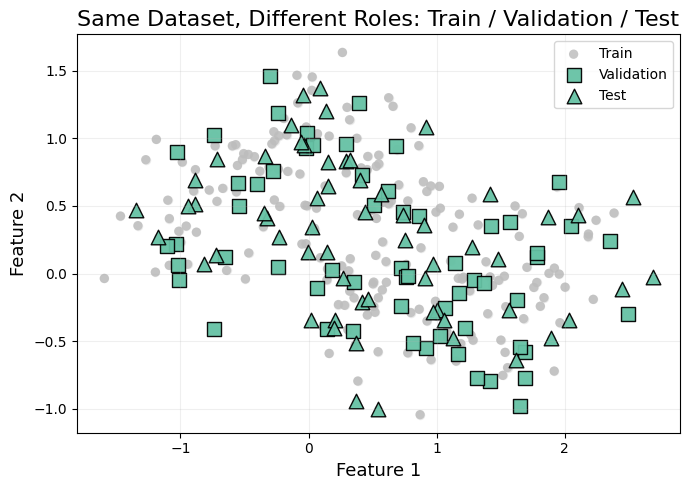

In [6]:
fig , ax = plt.subplots(figsize = (7 , 5))
ax.scatter(X[ : , 0] , X[ : , 1] , c = "lightgray" , s = 35 ,
           alpha = 0.35 , label = "_nolegend_")
ax.scatter(X_train[ : , 0] , X_train[ : , 1] , c = "#BDBDBD" , s = 45 ,
           alpha = 0.85 , marker = "o" , edgecolor = "none" , label = "Train")
ax.scatter(X_val[ : , 0] , X_val[ : , 1] , c = "#66C2A5" , s = 95 , alpha = 0.95 ,
           marker = "s" , edgecolor = "black" , linewidth = 1.0 , label = "Validation")
ax.scatter(X_test[ : , 0] , X_test[ : , 1] , c = "#66C2A5" , s = 110 , alpha = 0.95 ,
           marker = "^" , edgecolor = "black" , linewidth = 1.0 , label = "Test")
ax.set_title("Same Dataset, Different Roles: Train / Validation / Test")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend(loc = "upper right")
fig.tight_layout()
plt.show()

In [7]:
def plot_decision_boundary(model , X_all , y_all , title):
    x_min , x_max = X_all[ : , 0].min() - 0.5 , X_all[ : , 0].max() + 0.5
    y_min , y_max = X_all[ : , 1].min() - 0.5 , X_all[ : , 1].max() + 0.5
    xx , yy = np.meshgrid(np.linspace(x_min , x_max , 400) ,
                          np.linspace(y_min , y_max , 400))
    grid = np.c_[xx.ravel() , yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    fig , ax = plt.subplots(figsize = (7 , 5))
    ax.contourf(xx , yy , Z , alpha = 0.15 , cmap = plt.cm.Pastel1)
    ax.contour(xx , yy , Z , levels = [0.5] , colors = "#6A1B9A" , linewidths = 2.5)
    ax.scatter(X_all[y_all == 0 , 0] , X_all[y_all == 0 , 1] , s = 60 ,
               alpha = 0.80 , color = "#4C78A8" , label = "Class 0")
    ax.scatter(X_all[y_all == 1 , 0] , X_all[y_all == 1 , 1] , s = 60 ,
               alpha = 0.80 , color = "#F58518" , label = "Class 1")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc = "upper right")
    fig.tight_layout()
    plt.show()

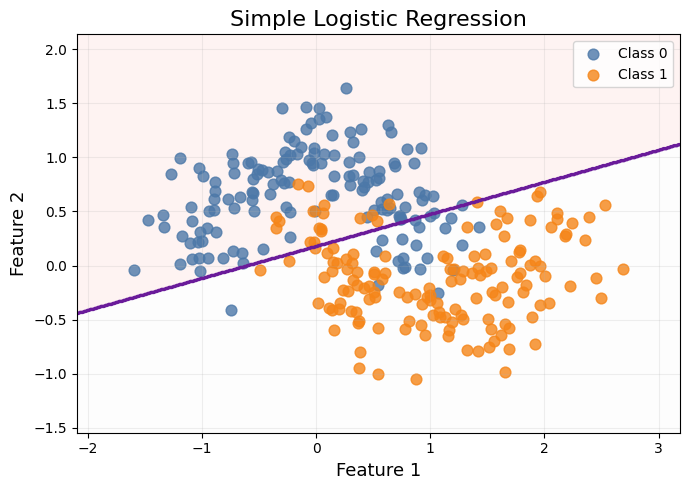

In [8]:
plot_decision_boundary(model_simple , X , y , "Simple Logistic Regression")

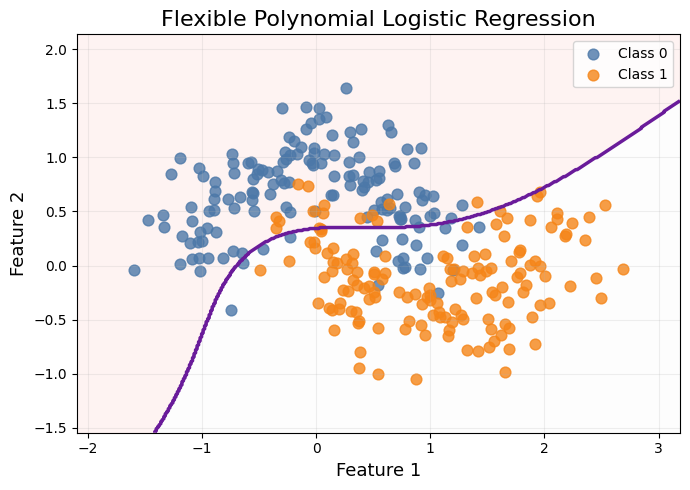

In [9]:
plot_decision_boundary(model_flexible , X , y , "Flexible Polynomial Logistic Regression")

[Text(0, 0, 'Simple'), Text(1, 0, 'Flexible')]

(0.75, 1.0)

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Logistic Regression Sanity Check: Train vs Validation vs Test')

Text(-0.24, 0.8827777777777778, '0.878')

Text(0.76, 0.905, '0.900')

Text(0.0, 0.8883333333333333, '0.883')

Text(1.0, 0.905, '0.900')

Text(0.24, 0.855, '0.850')

Text(1.2400000000000002, 0.8383333333333334, '0.833')

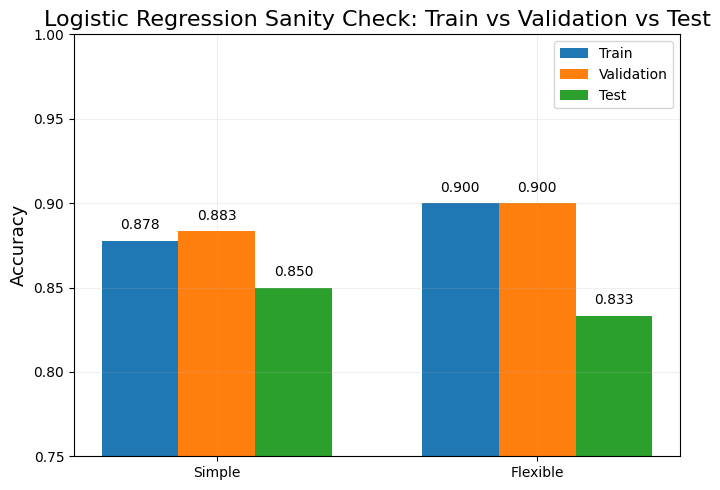

In [10]:
labels = ["Simple" , "Flexible"]
train_scores = [simple_train_acc , flex_train_acc]
val_scores = [simple_val_acc , flex_val_acc]
test_scores = [simple_test_acc , flex_test_acc]
x = np.arange(len(labels))
width = 0.24
fig , ax = plt.subplots(figsize = (7 , 5))
bars1 = ax.bar(x - width , train_scores , width , label = "Train")
bars2 = ax.bar(x , val_scores , width , label = "Validation")
bars3 = ax.bar(x + width , test_scores , width , label = "Test")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.75 , 1.00)
ax.set_ylabel("Accuracy")
ax.set_title("Logistic Regression Sanity Check: Train vs Validation vs Test")
ax.legend(loc = "upper right")
for bars in [bars1 , bars2 , bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2 , h + 0.005 , f"{h:.3f}" ,
                ha = "center" , va = "bottom" , fontsize = 10)
fig.tight_layout()
plt.show()

In [11]:
def plot_probability_surface(model , X_all , y_all , title):
    x_min , x_max = X_all[ : , 0].min() - 0.5 , X_all[ :  , 0].max() + 0.5
    y_min , y_max = X_all[ : , 1].min() - 0.5 , X_all[ : , 1].max() + 0.5
    xx , yy = np.meshgrid(np.linspace(x_min , x_max , 400) ,
                          np.linspace(y_min , y_max , 400))
    grid = np.c_[xx.ravel() , yy.ravel()]
    probs = model.predict_proba(grid)[ : , 1].reshape(xx.shape)
    fig , ax = plt.subplots(figsize = (7 , 5))
    ax.grid(False)
    contour = ax.contourf(xx , yy , probs , levels = 20 , alpha = 0.80 , cmap = "viridis")
    ax.contour(xx , yy , probs , levels = [0.5] , colors = "#D81B60" , linewidths = 2.4)
    ax.scatter(X_all[y_all == 0 , 0] , X_all[y_all == 0 , 1] , s = 45 ,
               alpha = 0.70 , color = "#4C78A8" , label = "Class 0")
    ax.scatter(X_all[y_all == 1 , 0] , X_all[y_all == 1 , 1] , s = 45 ,
               alpha = 0.70 , color = "#F58518" , label = "Class 1")
    cbar = fig.colorbar(contour)
    cbar.set_label("Predicted Probability of Class 1")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc = "upper right")
    fig.tight_layout()
    plt.show()

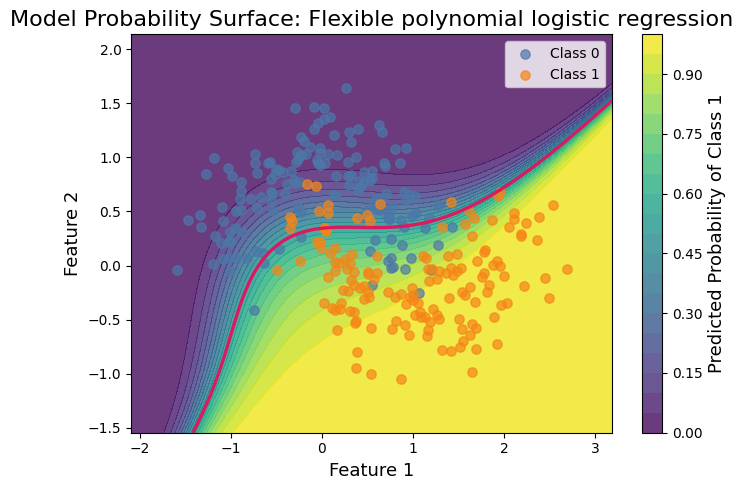

In [12]:
plot_probability_surface(selected_model , X , y ,
                         f"Model Probability Surface: {selected_name}")

Text(0.5, 1.0, 'Final Test Set Confusion Matrix')

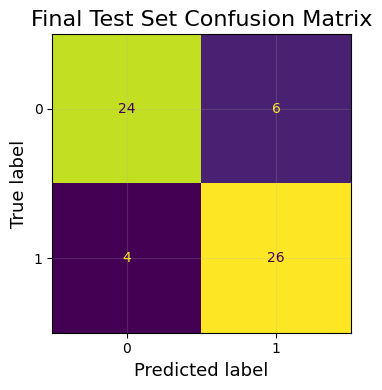

In [13]:
y_test_pred = selected_model.predict(X_test)
cm = confusion_matrix(y_test , y_test_pred)
fig , ax = plt.subplots(figsize = (5 , 4))
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(ax = ax , colorbar = False)
ax.set_title("Final Test Set Confusion Matrix")
fig.tight_layout()
plt.show()

(0.75, 1.0)

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Selected Model Check: Flexible polynomial logistic regression')

Text(0.0, 0.905, '0.900')

Text(1.0, 0.8383333333333334, '0.833')

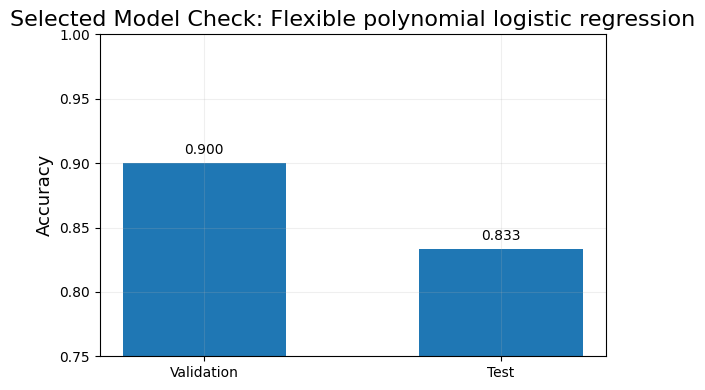

In [14]:
fig , ax = plt.subplots(figsize = (6 , 4))
summary_labels = ["Validation" , "Test"]
summary_scores = [selected_val_acc , selected_test_acc]
bars = ax.bar(summary_labels , summary_scores , width = 0.55)
ax.set_ylim(0.75 , 1.00)
ax.set_ylabel("Accuracy")
ax.set_title(f"Selected Model Check: {selected_name}")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2 , h + 0.005 , f"{h:.3f}" ,
            ha = "center" , va = "bottom" , fontsize = 10)
fig.tight_layout()
plt.show()

In [15]:
print("\n" , " " * 34 , "Takeaway")
print("-" * 78)
print("Choose models using validation performance, not test performance.")
print("Use test accuracy only once as a final check after model selection.")
print("If train is much higher than validation/test, watch for overfitting.")
print("If all three are low, the model may be underfitting.")
print("Logistic regression is more useful when you inspect both labels and probabilities.")
print("A validation winner may still do slightly worse on test due to sample variability.")


                                    Takeaway
------------------------------------------------------------------------------
Choose models using validation performance, not test performance.
Use test accuracy only once as a final check after model selection.
If train is much higher than validation/test, watch for overfitting.
If all three are low, the model may be underfitting.
Logistic regression is more useful when you inspect both labels and probabilities.
A validation winner may still do slightly worse on test due to sample variability.
